In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import os
import re
from tqdm import tqdm
import zarr

In [5]:
normalized_wave = []
normalized_spectra = []
normalized_continuum = []
source_files = []

def spectrum_sort_key(filename):
    match = re.search(r'spectrum(\d+)\.all$', filename)
    return int(match.group(1)) if match else filename

def mask_zero_only_gap(df):
    zero_columns = [
        'flux',
        'normed_flux',
        'normed_error',
        'smoothed_continuum',
        'continuum',
        'continuum_err',
        'segmentation',
        'segmentation_err',
    ]
    zero_gap = df[zero_columns].eq(0).all(axis=1)
    df.loc[zero_gap, ['normed_flux', 'continuum']] = np.nan
    return df

In [6]:
spectra_files = sorted(
    (file for file in os.listdir('normalized_spectra') if file.endswith('.all')),
    key=spectrum_sort_key,
)

for file in tqdm(spectra_files):
    df = pd.read_csv(os.path.join('normalized_spectra', file), sep=r'\s+')
    df = mask_zero_only_gap(df)
    source_files.append(file)
    normalized_wave.append(list(df['wave'].values))
    normalized_spectra.append(list(df['normed_flux'].values))
    normalized_continuum.append(list(df['continuum'].values))

100%|██████████| 22/22 [01:15<00:00,  3.42s/it]


In [7]:
# Find the maximum length among all spectra/waves/continua
max_len = max(len(w) for w in normalized_wave)

def pad_list(lst, desired_length, pad_value=np.nan):
    """Pad a list to the desired length with a pad_value."""
    return lst + [pad_value] * (desired_length - len(lst))

# Pad each list to max_len
normalized_wave = [pad_list(wv, max_len, pad_value=np.nan) for wv in normalized_wave]
normalized_spectra = [pad_list(s, max_len, pad_value=np.nan) for s in normalized_spectra]
normalized_continuum = [pad_list(c, max_len, pad_value=np.nan) for c in normalized_continuum]

Text(0.5, 1.0, 'spectrum10.all')

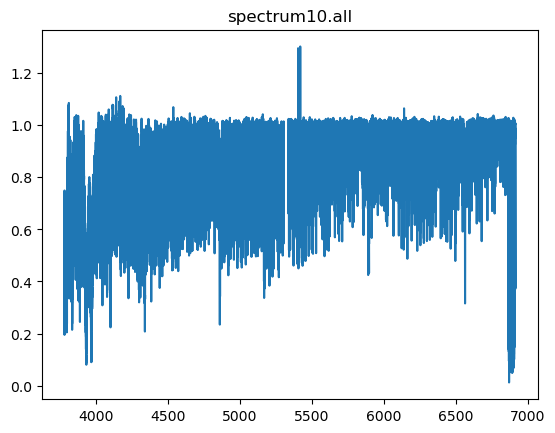

In [8]:
i = 10
file = f'normalized_spectra/spectrum{i}.all'
df = mask_zero_only_gap(pd.read_csv(file, sep=r'\s+'))
plt.plot(df['wave'], df['normed_flux'])
plt.title(os.path.basename(file))

In [9]:
import zarr

o = zarr.open_group('harps_data.zarr')
o.tree()

/
├── bjds (22,) float64
├── continuum (22, 313193) float64
├── errors (22, 313193) float32
├── exptimes (22,) float64
├── fluxes (22, 313193) float32
├── mjd_ends (22,) float64
├── mjd_starts (22,) float64
├── normalized_flux (22, 313193) float64
├── normalized_wave (22, 313193) float64
├── phases (22,) float64
├── snrs (22,) float64
└── wavelengths (22, 313193) float64

In [10]:
wavelengths = o['wavelengths'][:]
fluxes = o['fluxes'][:]

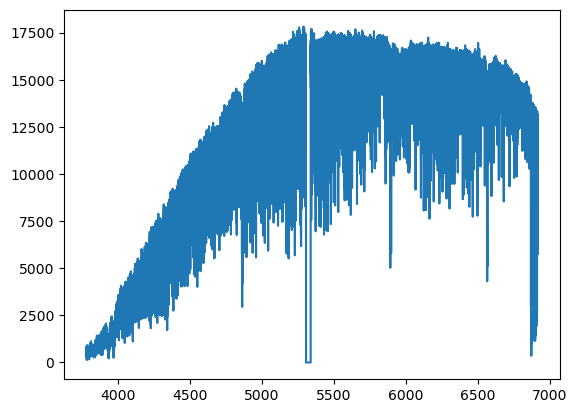

In [11]:
i = 12
plt.plot(wavelengths[i], fluxes[i])

In [12]:
import numpy as np

# Convert lists to numpy arrays for saving
normalized_wave_arr = np.array(normalized_wave)
normalized_flux_arr = np.array(normalized_spectra)
normalized_continuum_arr = np.array(normalized_continuum)

# Save to Zarr in a deterministic row order and keep provenance metadata for each row.
o.create_array("normalized_wave", data=normalized_wave_arr, overwrite=True, fill_value=np.nan)
o.create_array("normalized_flux", data=normalized_flux_arr, overwrite=True, fill_value=np.nan)
o.create_array("continuum", data=normalized_continuum_arr, overwrite=True, fill_value=np.nan)
o.attrs['normalized_flux_source_files'] = source_files

print("normalized_wave, normalized_flux, continuum, and normalized_flux_source_files have been added to the Zarr group.")

normalized_wave, normalized_flux, continuum, and normalized_flux_source_files have been added to the Zarr group.
